# Aula 06

![](../../data/imagem/banner-pos-2022.jpg)

-----------

# Importando Bibliotecas

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import YOLO

# Detecção de Objetos


In [8]:
PATH_DIR = "../../data"

input_folder = os.path.join(PATH_DIR, 'human_tracking', 'images')

sorted(os.listdir(input_folder))[:5]

['frame_000000.PNG',
 'frame_000001.PNG',
 'frame_000002.PNG',
 'frame_000003.PNG',
 'frame_000004.PNG']

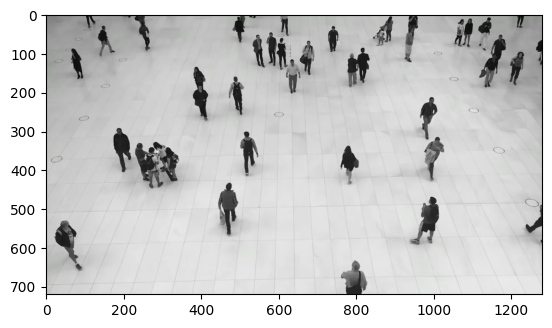

In [9]:
index = 0
image_path = os.path.join(input_folder, sorted(os.listdir(input_folder))[index])

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.show()

In [14]:
# Load the YOLO11 model
model_yolo11n = YOLO("yolo11n.pt")
model_yolo11l = YOLO("yolo11l.pt")

100%|██████████| 49.0M/49.0M [00:02<00:00, 19.6MB/s]


In [18]:
results_yolo11n = model_yolo11n.predict(img)

results_yolo11l = model_yolo11l.predict(img)


0: 384x640 15 persons, 118.4ms
Speed: 4.1ms preprocess, 118.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 20 persons, 1016.4ms
Speed: 1.8ms preprocess, 1016.4ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


In [19]:
results_yolo11n[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

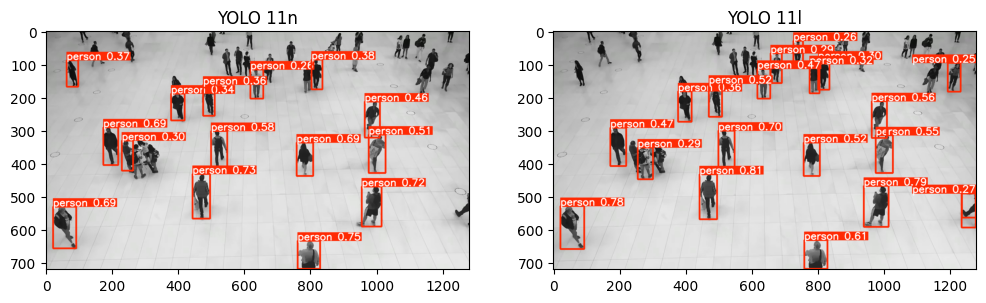

In [20]:
img_annotated_yolo11n = results_yolo11n[0].plot()
img_annotated_yolo11l = results_yolo11l[0].plot()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax[0].imshow(img_annotated_yolo11n)
ax[0].set_title('YOLO 11n')
ax[1].imshow(img_annotated_yolo11l)
ax[1].set_title('YOLO 11l')
plt.show()

In [22]:
# Open the video file
video_path = '../../data/human_tracking/human_tracking.mp4'
cap = cv2.VideoCapture(video_path)

# Loop through the video frames
while cap.isOpened():
    # Read a frame from the video
    success, frame = cap.read()

    if success:
        # Run YOLO11 tracking on the frame, persisting tracks between frames
        results = model_yolo11n.predict(frame, verbose=False)

        # Visualize the results on the frame
        annotated_frame = results[0].plot()

        # Display the annotated frame
        cv2.imshow("YOLO 11n", annotated_frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        # Break the loop if the end of the video is reached
        break

# Release the video capture object and close the display window
cap.release()
cv2.destroyAllWindows()

# Isolamento de objetos segmentados

Depois de executar a Tarefa de Segmento, às vezes é desejável extrair os objetos isolados dos resultados da inferência. Este guia fornece uma receita genérica sobre como fazer isso usando o Ultralytics Predict Mode.

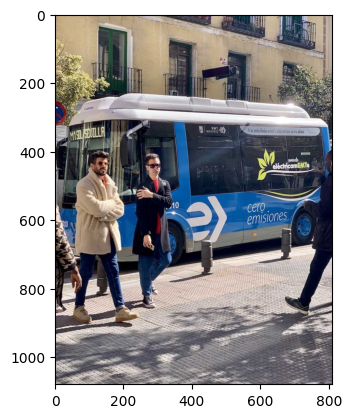

In [3]:
PATH_DIR = "../../data/imagem"

image_path = os.path.join(PATH_DIR, "bus.jpg")

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.show()

In [4]:
# Load a model
model = YOLO("yolo11n-seg.pt")

# Run inference
results = model.predict(image_path)


image 1/1 /home/octavio/PUC_MG/curso/Analise_de_Imagens_e_Visao_Computacional/scripts/aula_06/../../data/imagem/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 2640.9ms
Speed: 110.2ms preprocess, 2640.9ms inference, 166.5ms postprocess per image at shape (1, 3, 640, 480)


In [5]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair

In [7]:
results[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [8]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0., 11.,  0.])
conf: tensor([0.8985, 0.8849, 0.8628, 0.8223, 0.4611, 0.4428])
data: tensor([[1.9683e+01, 2.3003e+02, 8.0179e+02, 7.4414e+02, 8.9853e-01, 5.0000e+00],
        [6.7014e+02, 3.9057e+02, 8.0955e+02, 8.7529e+02, 8.8493e-01, 0.0000e+00],
        [4.9487e+01, 3.9813e+02, 2.4076e+02, 9.0509e+02, 8.6281e-01, 0.0000e+00],
        [2.2265e+02, 4.0454e+02, 3.4606e+02, 8.5989e+02, 8.2234e-01, 0.0000e+00],
        [1.1447e-01, 2.5458e+02, 3.1959e+01, 3.2565e+02, 4.6114e-01, 1.1000e+01],
        [0.0000e+00, 5.5533e+02, 7.4818e+01, 8.7502e+02, 4.4278e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[410.7375, 487.0835, 782.1091, 514.1113],
        [739.8477, 632.9327, 139.4077, 484.7192],
        [145.1215, 651.6073, 191.2684, 506.9590],
        [284.3539, 632.2175, 123.4095, 455.3473],
        [ 16.0369, 290.1146,  31.8448,  71.0691],
     

In [9]:
len(results[0].boxes.cls)

6

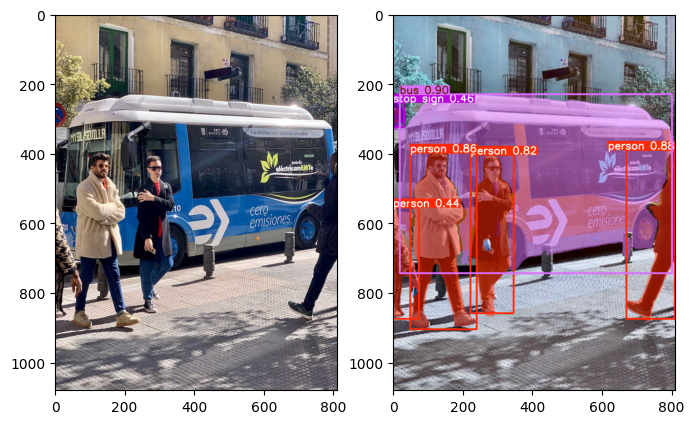

In [12]:
img_annotated = results[0].plot()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,5))
ax[0].imshow(img)
ax[1].imshow(img_annotated)
plt.show()

In [13]:
for ci, c in enumerate(results[0]):
    idx = c.boxes.cls.tolist().pop()
    print(f"Index: {ci}, Label: {c.names[idx]}")

Index: 0, Label: bus
Index: 1, Label: person
Index: 2, Label: person
Index: 3, Label: person
Index: 4, Label: stop sign
Index: 5, Label: person


In [14]:
b_mask = np.zeros(img.shape[:2], dtype='uint8')

contour = results[0].masks.xy[2]
contour = contour.astype(np.int32)

contour = contour.reshape(-1, 1, 2)
contour.shape

(316, 1, 2)

In [15]:
b_mask = cv2.drawContours(b_mask, [contour], -1, (255, 255, 255), cv2.FILLED)

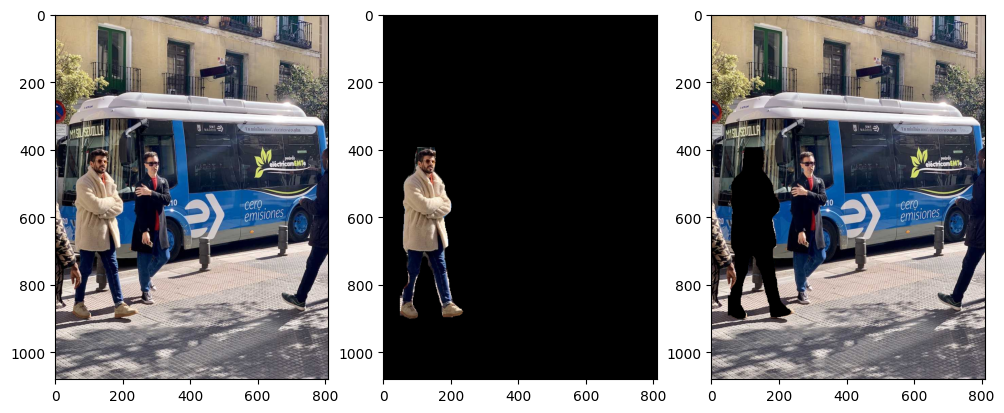

In [16]:
mask3ch = cv2.cvtColor(b_mask, cv2.COLOR_GRAY2RGB)

isolate = cv2.bitwise_and(img, mask3ch)
remove = cv2.bitwise_and(img, cv2.bitwise_not(mask3ch))

fig, ax = plt.subplots(ncols=3, figsize=(12,5))

ax[0].imshow(img)
ax[1].imshow(isolate)
ax[2].imshow(remove)
plt.show()

# Rastreio

O rastreio de múltiplos objectos na análise de vídeo envolve a identificação de objectos e a manutenção de uma identificação única para cada objeto detectado em todos os fotogramas de vídeo. Ultralytics YOLO suporta isto, fornecendo rastreio em tempo real juntamente com IDs de objectos, facilitando tarefas como a vigilância de segurança e a análise de desportos. O sistema utiliza rastreadores como o `BoT-SORT` e o `ByteTrack`, que podem ser configurados através de ficheiros YAML.

In [ ]:
# Load the YOLO11 model
model = YOLO("yolo11n.pt")

In [18]:
# Open the video file
video_path = '../../data/human_tracking/human_tracking.mp4'
cap = cv2.VideoCapture(video_path)

# Loop through the video frames
while cap.isOpened():
    # Read a frame from the video
    success, frame = cap.read()

    if success:
        # Run YOLO11 tracking on the frame, persisting tracks between frames
        results = model.track(frame, persist=True, verbose=False)

        # Visualize the results on the frame
        annotated_frame = results[0].plot()

        # Display the annotated frame
        cv2.imshow("YOLO11 Tracking", annotated_frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        # Break the loop if the end of the video is reached
        break

# Release the video capture object and close the display window
cap.release()
cv2.destroyAllWindows()

Para visualizar trajectos de objectos em vários fotogramas de vídeo, pode utilizar as funcionalidades de seguimento do modelo YOLO juntamente com o OpenCV para desenhar os trajectos dos objectos detectados.

In [19]:
from collections import defaultdict

In [21]:
# Load the YOLO11 model
model = YOLO("yolo11n.pt")

# Open the video file
video_path = '../../data/human_tracking/human_tracking.mp4'
cap = cv2.VideoCapture(video_path)

# Store the track history
track_history = defaultdict(lambda: [])

# Loop through the video frames
while cap.isOpened():
    # Read a frame from the video
    success, frame = cap.read()

    if success:
        # Run YOLO11 tracking on the frame, persisting tracks between frames
        result = model.track(frame, persist=True, verbose=False)[0]

        # Get the boxes and track IDs
        if result.boxes and result.boxes.is_track:
            boxes = result.boxes.xywh.cpu()
            track_ids = result.boxes.id.int().cpu().tolist()

            # Visualize the result on the frame
            frame = result.plot()

            # Plot the tracks
            for box, track_id in zip(boxes, track_ids):
                x, y, w, h = box
                track = track_history[track_id]
                track.append((float(x), float(y)))  # x, y center point
                if len(track) > 30:  # retain 30 tracks for 30 frames
                    track.pop(0)

                # Draw the tracking lines
                points = np.hstack(track).astype(np.int32).reshape((-1, 1, 2))
                cv2.polylines(frame, [points], isClosed=False, color=(0, 230, 230), thickness=10)

        # Display the annotated frame
        cv2.imshow("YOLO11 Tracking", frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    else:
        # Break the loop if the end of the video is reached
        break

# Release the video capture object and close the display window
cap.release()
cv2.destroyAllWindows()